In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
import pandas as pd

# load csv file
csv_filename = '/data/overall_data.csv'
df = pd.read_csv(csv_filename)

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Label'], errors='ignore')
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Classifier

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42) # criterion='gini'
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7974


In [20]:
# Extract and plot feature importance
feature_importances = clf.feature_importances_
features = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print feature importances
print("\nFeature Importances:")
print(importance_df)


Feature Importances:
                              Feature  Importance
21                 std_outgoing_burst    0.037261
19                      std_total_cum    0.032598
17                   std_incoming_cum    0.032430
1                        num_outgoing    0.032236
49                   std_dev_interval    0.030264
31                num_incoming_thirty    0.030218
16                          std_total    0.030103
27                      avg_total_cum    0.029968
29                 avg_burst_outgoing    0.029844
25                          avg_total    0.029479
32                num_outgoing_thirty    0.029415
50                     range_interval    0.029190
47                       max_interval    0.029171
13                  fraction_outgoing    0.029038
26                   avg_cum_incoming    0.028925
28                 avg_burst_incoming    0.028240
30                    avg_total_burst    0.028087
12                  fraction_incoming    0.028042
44                     max_t

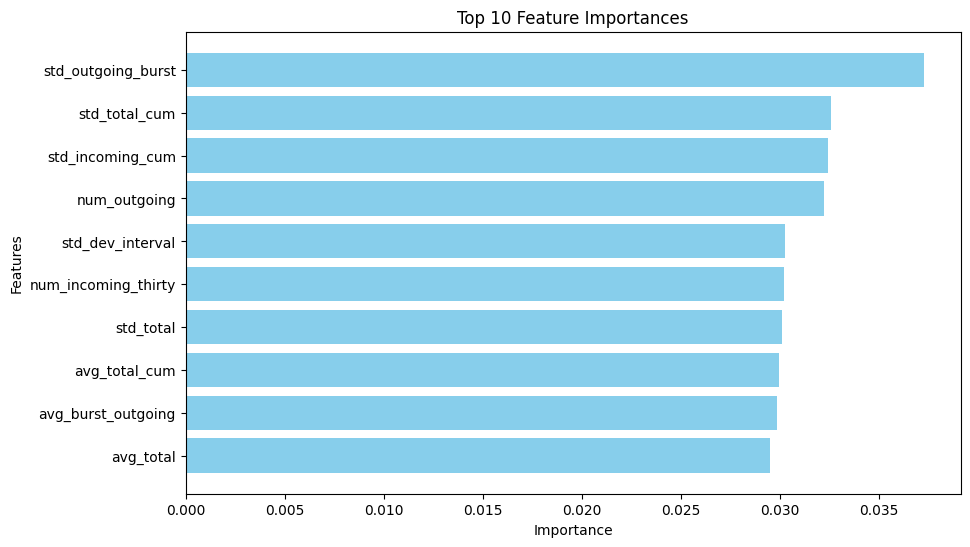

In [21]:
import matplotlib.pyplot as plt

# top 10 feature importance
top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

In [5]:
# List of features to exclude based on the provided image
features_to_exclude = [
    "avg_timestamps", "std_incoming_burst", "std_outgoing_cum", "num_outgoing_cum", "num_outgoing_thirty_burst",
    "num_outgoing_last_thirty_burst", "num_incoming_thirty_burst", "num_incoming_last_thirty_burst",
    "num_outgoing_thirty_cum", "num_incoming_thirty_cum", "num_outgoing_last_thirty_cum",
    "num_incoming_last_thirty_cum", "avg_outgoing", "min_interval",
]

# Exclude these features from the dataset
X_filtered = X.drop(columns=features_to_exclude, errors='ignore')

# Split the data into training and testing sets
X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
    X_filtered, y, test_size=0.2, random_state=42
)

# Retrain the Random Forest classifier with the filtered dataset
clf_filtered = RandomForestClassifier(n_estimators=100, random_state=42)
clf_filtered.fit(X_train_filtered, y_train_filtered)

# Make predictions and evaluate accuracy
y_pred_filtered = clf_filtered.predict(X_test_filtered)
accuracy_filtered = accuracy_score(y_test_filtered, y_pred_filtered)

# Print the new accuracy
print(f'Accuracy after removing selected features: {accuracy_filtered:.4f}')

Accuracy after removing selected features: 0.8034


## k-NN

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# KNN 모델 학습
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, y_train)

# 테스트 데이터에 대한 예측
y_pred = knn.predict(X_test)

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7084
